# Week 6 Lab: Regression Diagnostics Demo (Simulated Data)

**QM 2023 — Statistics II / Data Analytics**  
**Spring 2026 | University of Tulsa**

---

## What You Will Learn

By the end of this demo, you will be able to:

1. **Generate** simulated data with heteroskedasticity (variance increases with X)
2. **Fit** OLS regression and interpret the output
3. **Create** diagnostic plots: Residuals vs Fitted, Q-Q, Scale-Location, Residuals vs Leverage
4. **Run** the Breusch-Pagan test for heteroskedasticity
5. **Apply** robust standard errors (HC3) when heteroskedasticity is detected
6. **Compute** VIF to check for multicollinearity

---

### The Setup

This demo uses **simulated data** with two predictors:
- **Firm Size** (millions) → Revenue (heteroskedastic: larger firms have more variable revenue)
- **Firm Age** (years) → Revenue (independent of size, so VIF stays low)

We intentionally violate the homoskedasticity assumption to demonstrate how to detect and fix it.

---

## Setup: Imports and Configuration

In [14]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import ProbPlot

# Output directory: same folder as this notebook
# Run this notebook from demos/diagnostics/ so figures save next to the notebook
OUTPUT_DIR = Path(".")

print("Imports successful!")

Imports successful!


---

## Step 1: Generate Simulated Data with Heteroskedasticity

**Why simulate heteroskedasticity?** In the real world, larger firms often have more variable revenue than smaller firms—their error variance increases with size. OLS assumes constant variance (homoskedasticity); when that fails, we need to detect it and use robust standard errors.

We create 200 observations with two predictors:
- **Firm Size** (10 to 1000 millions): sorted to produce a clean funnel pattern in the residuals
- **Firm Age** (1 to 50 years): independent of size, so we can later check VIF without multicollinearity
- **Errors**: Variance increases with firm size ($\sigma = 5 + 0.08 \times \text{size}$)
- **Revenue** (Y): $\text{Revenue} = 20 + 0.5 \times \text{Firm\_Size} + 1.0 \times \text{Firm\_Age} + \varepsilon$ — this is the data-generating equation; the regression we fit in Step 2 has the same form.

In [15]:
np.random.seed(123)
n = 200

# X1: Firm size (in millions) - 10 to 1000 (sorted for clean heteroskedasticity pattern)
firm_size = np.sort(np.random.uniform(10, 1000, n))

# X2: Firm age (in years) - 1 to 50, INDEPENDENT of firm_size (avoids multicollinearity)
np.random.seed(456)
firm_age = np.random.uniform(1, 50, n)

# Heteroskedastic errors: variance increases with firm size
sigma = 5 + 0.08 * firm_size
errors = np.random.normal(0, sigma, n)

# Y: Revenue = base + size_effect + age_effect + error
beta_0, beta_1, beta_2 = 20, 0.5, 1.0
revenue = beta_0 + beta_1 * firm_size + beta_2 * firm_age + errors

df = pd.DataFrame({
    'Firm_Size': firm_size,
    'Firm_Age': firm_age,
    'Revenue': revenue
})

display(df.head(10).style.set_caption("First 10 observations").format("{:.2f}"))
display(df.describe().style.format("{:.2f}").set_caption("Descriptive statistics"))

,Firm_Size,Firm_Age,Revenue
0,12.66,13.19,38.55
1,17.35,8.99,26.56
2,25.97,39.40,76.96
3,39.03,40.62,73.50
4,41.88,31.66,69.81
5,53.16,30.60,74.31
6,58.09,44.40,82.34
7,69.08,38.20,75.12
8,88.36,9.87,74.96
9,88.57,8.36,81.70


,Firm_Size,Firm_Age,Revenue
count,200.00,200.00,200.00
mean,508.24,24.41,299.70
std,263.73,14.24,143.69
min,12.66,1.38,26.56
25%,311.56,11.43,193.50
50%,525.56,24.95,302.50
75%,721.00,35.99,400.41
max,995.40,49.95,661.58


---

## Explore the Data: Summary Statistics and Distributions

Before running regression, we explore the data to understand distributions and relationships. The six panels below show: (1) how Firm Size is distributed, (2) how Firm Age is distributed, (3) how Revenue is distributed, (4) how Revenue relates to Firm Size, (5) how Revenue relates to Firm Age, and (6) the correlation matrix. This helps us interpret the regression results and spot potential issues like heteroskedasticity.

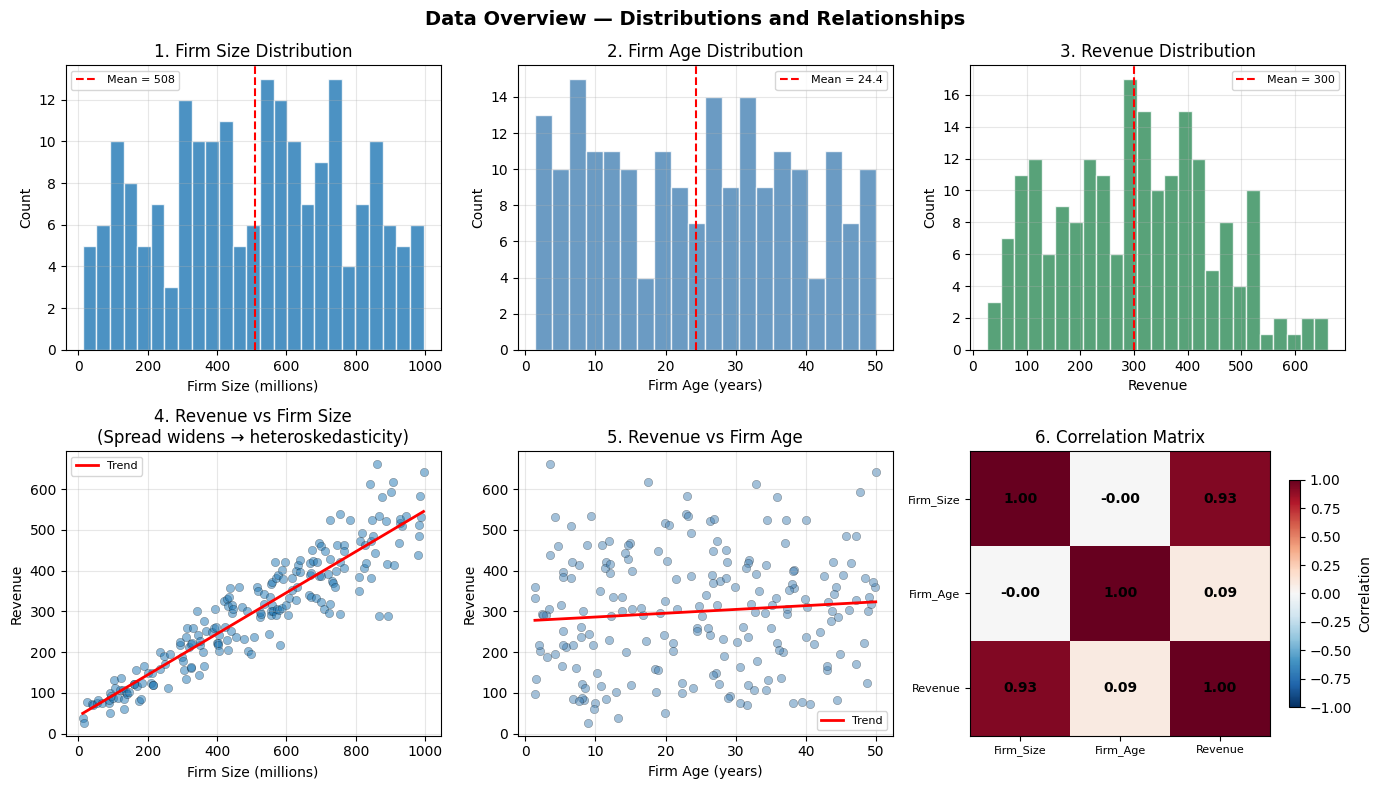

In [16]:
# Six-panel exploratory summary: distributions + relationships + correlation
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Data Overview — Distributions and Relationships', fontsize=14, fontweight='bold')

# Panel 1: Firm Size distribution
axes[0, 0].hist(df['Firm_Size'], bins=25, edgecolor='white', alpha=0.8)
axes[0, 0].set_xlabel('Firm Size (millions)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('1. Firm Size Distribution')
axes[0, 0].axvline(df['Firm_Size'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {df["Firm_Size"].mean():.0f}')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Firm Age distribution
axes[0, 1].hist(df['Firm_Age'], bins=20, edgecolor='white', alpha=0.8, color='steelblue')
axes[0, 1].set_xlabel('Firm Age (years)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('2. Firm Age Distribution')
axes[0, 1].axvline(df['Firm_Age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {df["Firm_Age"].mean():.1f}')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Revenue distribution
axes[0, 2].hist(df['Revenue'], bins=25, edgecolor='white', alpha=0.8, color='seagreen')
axes[0, 2].set_xlabel('Revenue')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('3. Revenue Distribution')
axes[0, 2].axvline(df['Revenue'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {df["Revenue"].mean():.0f}')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# Panel 4: Revenue vs Firm Size (notice spread widens with size → heteroskedasticity)
axes[1, 0].scatter(df['Firm_Size'], df['Revenue'], alpha=0.5, edgecolors='k', linewidth=0.3)
axes[1, 0].set_xlabel('Firm Size (millions)')
axes[1, 0].set_ylabel('Revenue')
axes[1, 0].set_title('4. Revenue vs Firm Size\n(Spread widens → heteroskedasticity)')
z1 = np.polyfit(df['Firm_Size'], df['Revenue'], 1)
p1 = np.poly1d(z1)
x1 = np.linspace(df['Firm_Size'].min(), df['Firm_Size'].max(), 100)
axes[1, 0].plot(x1, p1(x1), 'r-', linewidth=2, label='Trend')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Panel 5: Revenue vs Firm Age
axes[1, 1].scatter(df['Firm_Age'], df['Revenue'], alpha=0.5, edgecolors='k', linewidth=0.3, color='steelblue')
axes[1, 1].set_xlabel('Firm Age (years)')
axes[1, 1].set_ylabel('Revenue')
axes[1, 1].set_title('5. Revenue vs Firm Age')
z2 = np.polyfit(df['Firm_Age'], df['Revenue'], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df['Firm_Age'].min(), df['Firm_Age'].max(), 100)
axes[1, 1].plot(x2, p2(x2), 'r-', linewidth=2, label='Trend')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# Panel 6: Correlation heatmap
corr = df[['Firm_Size', 'Firm_Age', 'Revenue']].corr()
im = axes[1, 2].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1, 2].set_xticks(range(3))
axes[1, 2].set_yticks(range(3))
axes[1, 2].set_xticklabels(['Firm_Size', 'Firm_Age', 'Revenue'], fontsize=8)
axes[1, 2].set_yticklabels(['Firm_Size', 'Firm_Age', 'Revenue'], fontsize=8)
for i in range(3):
    for j in range(3):
        axes[1, 2].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=axes[1, 2], label='Correlation', shrink=0.8)
axes[1, 2].set_title('6. Correlation Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_overview_simulated.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 2: Fit OLS Regression

We fit an OLS model to predict **Revenue** from **Firm Size** and **Firm Age**. The regression equation is:

$$\text{Revenue} = \beta_0 + \beta_1 \cdot \text{Firm\_Size} + \beta_2 \cdot \text{Firm\_Age} + \varepsilon$$

**Left-hand side (Y):**
- **Revenue** = outcome variable we are trying to predict

**Right-hand side (predictors):**
- **β₀** = intercept (constant term)
- **β₁** = coefficient on Firm_Size (firm size in millions)
- **β₂** = coefficient on Firm_Age (firm age in years)
- **ε** = error term (residual)

The **estimated** equation (with numerical coefficients from the table below) has the form: $\widehat{\text{Revenue}} = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{Firm\_Size} + \hat{\beta}_2 \cdot \text{Firm\_Age}$.

**R-squared** tells us what fraction of the variation in Revenue is explained by our predictors. The **coefficients** give the estimated effect of each predictor (holding the other constant). We will use this model to run diagnostics and see whether our standard errors are trustworthy.

In [17]:
# Define outcome (Y) and predictors explicitly — easier for students to interpret
y_revenue = df['Revenue']                        # Outcome: Revenue (what we're predicting)
X_predictors = df[['Firm_Size', 'Firm_Age']]     # Predictors: Firm_Size and Firm_Age
X_design = sm.add_constant(X_predictors)          # Design matrix: intercept + Firm_Size + Firm_Age

# Fit OLS: Revenue = β₀ + β₁(Firm_Size) + β₂(Firm_Age) + ε
# We write sm.OLS(y, X).fit() with our actual variables every time
model = sm.OLS(y_revenue, X_design).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Revenue   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     633.4
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.59e-86
Time:                        13:08:57   Log-Likelihood:                -1076.3
No. Observations:                 200   AIC:                             2159.
Df Residuals:                     197   BIC:                             2168.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.4684     10.387      1.971      0.050      -0.015      40.952
Firm_Size      0.5043      0.014     35.417      0.000       0.476       0.532
Firm_Age       0.9383      0.264      3.558      0.000       0.418       1.458
==============================================================================
Omnibus:                       14.954   Durbin-Watson:                   2.137
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               36.981
Skew:                          -0.230   Prob(JB):                     9.32e-09
Kurtosis:                       5.056   Cond. No.                     1.59e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.59e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

---

## Step 2b: Line of Best Fit — Actual vs Predicted Revenue

**What does this plot show?** We compare actual **Revenue** (Y) to predicted Revenue (ŷ) from our fitted equation:

$$\widehat{\text{Revenue}} = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{Firm\_Size} + \hat{\beta}_2 \cdot \text{Firm\_Age}$$

The **45° line** (y = x) represents perfect prediction—if every point lay on it, our model would be exact. Points scatter around this line; the spread tells us how much error remains. A good model has points clustered near the line.

Saved: line_of_best_fit_simulated.png


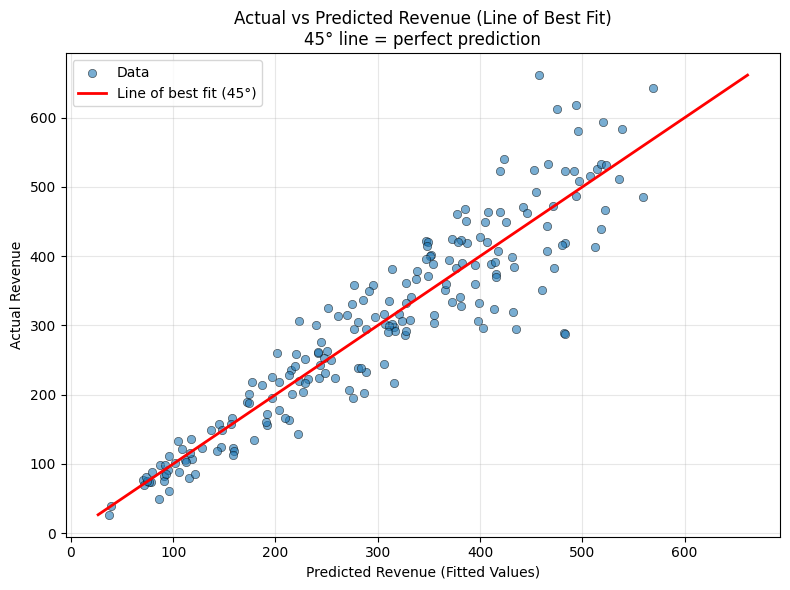

In [18]:
# Extract actual and predicted Revenue — write out variables so students can interpret
actual_revenue = df['Revenue']                   # Actual Revenue (Y)
predicted_revenue = model.fittedvalues           # Predicted Revenue (ŷ) from our regression

min_val = min(actual_revenue.min(), predicted_revenue.min())
max_val = max(actual_revenue.max(), predicted_revenue.max())

fig_fit, ax_fit = plt.subplots(figsize=(8, 6))
ax_fit.scatter(predicted_revenue, actual_revenue, alpha=0.6, edgecolors='k', linewidth=0.5, label='Data')
ax_fit.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Line of best fit (45°)')
ax_fit.set_xlabel('Predicted Revenue (Fitted Values)')
ax_fit.set_ylabel('Actual Revenue')
ax_fit.set_title('Actual vs Predicted Revenue (Line of Best Fit)\n45° line = perfect prediction')
ax_fit.legend()
ax_fit.grid(True, alpha=0.3)
plt.tight_layout()
out_fit = OUTPUT_DIR / 'line_of_best_fit_simulated.png'
plt.savefig(out_fit, dpi=150, bbox_inches='tight')
print(f"Saved: {out_fit}")
plt.show()

---

## Step 3: Diagnostic Plots

Before trusting our regression results, we check four diagnostic plots. Each plot tests a different assumption: constant variance (homoskedasticity), normality of errors, and whether any single observation has undue influence. We will look at each plot one at a time to understand what to look for, then view all four together.

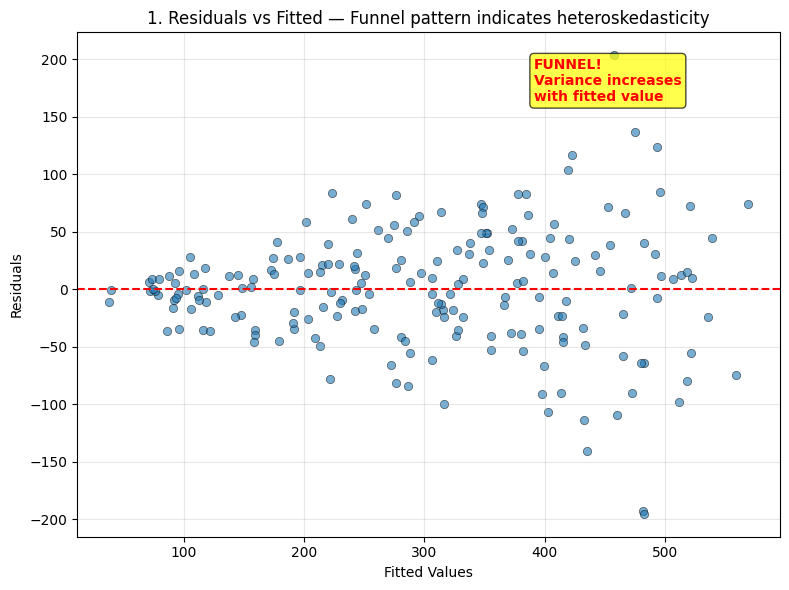

In [19]:
# Define each variable separately — easier for students to interpret
predicted_revenue = model.fittedvalues             # Predicted Revenue (ŷ)
residuals = model.resid                           # Residuals = actual Revenue − predicted Revenue
standardized_residuals = model.resid_pearson      # Standardized residuals (for Q-Q and scale-location)

fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.scatter(predicted_revenue, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('1. Residuals vs Fitted — Funnel pattern indicates heteroskedasticity')
ax1.annotate('FUNNEL!\nVariance increases\nwith fitted value', 
             xy=(0.65, 0.95), xycoords='axes fraction', fontsize=10,
             verticalalignment='top', color='red', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residuals_vs_fitted_simulated.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot 2: Normal Q-Q Plot

**Purpose:** Checks whether the residuals are approximately normally distributed. OLS inference (t-tests, confidence intervals) relies on normality, especially in smaller samples.

**What to look for:** Points should follow the diagonal line closely. If points curve away at the tails (heavy tails) or form an S-shape, the residuals may not be normal. With large samples, the Central Limit Theorem often makes this less critical.

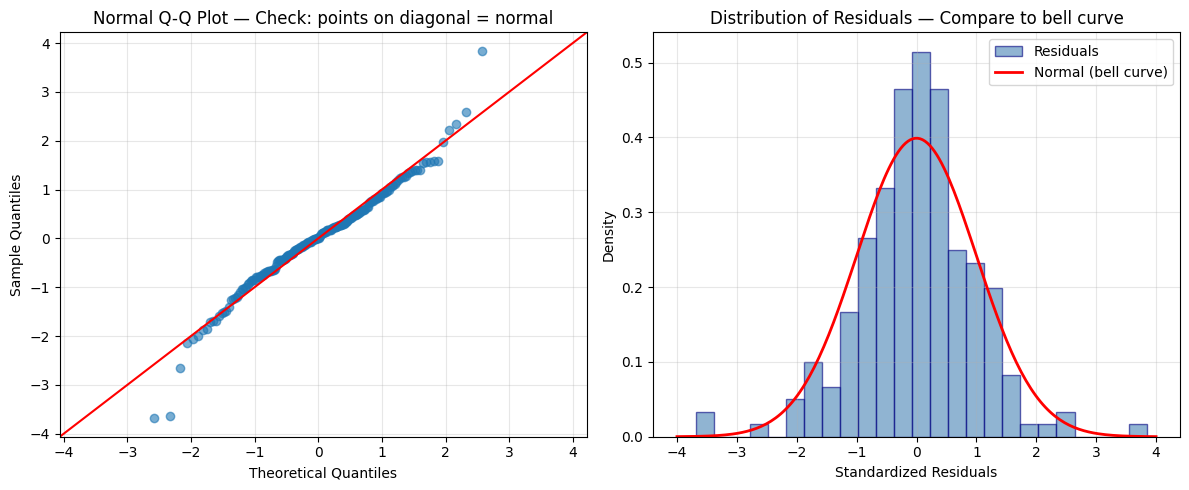

In [20]:
# Define variables explicitly — easier for students to interpret
predicted_revenue = model.fittedvalues             # Predicted Revenue (ŷ)
residuals = model.resid                           # Residuals = actual Revenue − predicted Revenue
standardized_residuals = model.resid_pearson      # Standardized residuals (for Q-Q plot)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# Left: Q-Q plot
ax_qq = axes2[0]
ProbPlot(standardized_residuals).qqplot(line='45', ax=ax_qq, alpha=0.6)
ax_qq.set_title('Normal Q-Q Plot — Check: points on diagonal = normal')
ax_qq.set_xlabel('Theoretical Quantiles')
ax_qq.set_ylabel('Sample Quantiles')
ax_qq.grid(True, alpha=0.3)

# Right: Histogram of residuals with normal bell curve overlay
ax_hist = axes2[1]
ax_hist.hist(standardized_residuals, bins=25, density=True, alpha=0.6, color='steelblue', edgecolor='navy', label='Residuals')
x_bell = np.linspace(-4, 4, 200)
bell_curve = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_bell**2)
ax_hist.plot(x_bell, bell_curve, 'r-', linewidth=2, label='Normal (bell curve)')
ax_hist.set_xlabel('Standardized Residuals')
ax_hist.set_ylabel('Density')
ax_hist.set_title('Distribution of Residuals — Compare to bell curve')
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)

plt.tight_layout()
out2 = OUTPUT_DIR / 'qq_plot_simulated.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()

### Plot 3: Scale-Location

**Purpose:** Another way to spot heteroskedasticity. We plot √|standardized residuals| vs fitted values. Under homoskedasticity, the spread should be roughly horizontal. **What to look for:** An upward trend (spread increases with fitted values) indicates heteroskedasticity—exactly what we expect in this simulated data.

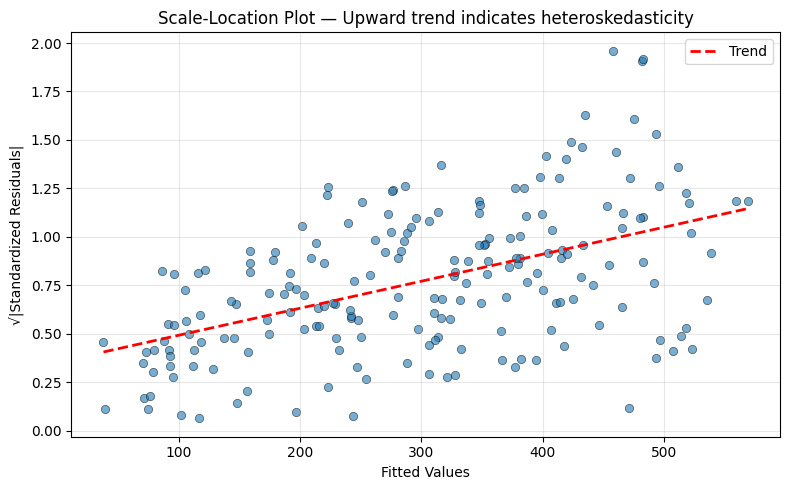

In [21]:
# Define variables explicitly — easier for students to interpret
predicted_revenue = model.fittedvalues             # Predicted Revenue (ŷ)
residuals = model.resid                           # Residuals = actual Revenue − predicted Revenue
standardized_residuals = model.resid_pearson      # Standardized residuals

fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.scatter(predicted_revenue, np.sqrt(np.abs(standardized_residuals)), alpha=0.6, edgecolors='k', linewidth=0.5)
z = np.polyfit(predicted_revenue, np.sqrt(np.abs(standardized_residuals)), 1)
p = np.poly1d(z)
ax3.plot(sorted(predicted_revenue), p(sorted(predicted_revenue)), "r--", linewidth=2, label='Trend')
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('√|Standardized Residuals|')
ax3.set_title('Scale-Location Plot — Upward trend indicates heteroskedasticity')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scale_location_simulated.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot 4: Residuals vs Leverage

**Purpose:** Identifies influential observations. **Leverage** measures how far an observation's predictors are from the average; high-leverage points can disproportionately pull the regression line. **What to look for:** Points far to the right (high leverage) with large residuals may be influential outliers. Cook's distance (not shown) combines leverage and residual size.

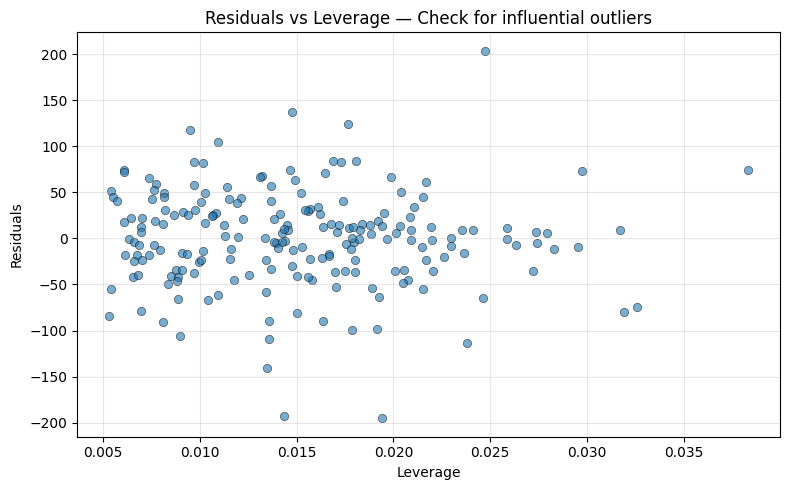

In [22]:
# Define variables explicitly — easier for students to interpret
residuals = model.resid                           # Residuals = actual Revenue − predicted Revenue
leverage = model.get_influence().hat_matrix_diag  # Leverage: how far each observation's predictors are from the mean

fig4, ax4 = plt.subplots(figsize=(8, 5))
ax4.scatter(leverage, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
ax4.set_xlabel('Leverage')
ax4.set_ylabel('Residuals')
ax4.set_title('Residuals vs Leverage — Check for influential outliers')
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residuals_vs_leverage_simulated.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 4: Breusch-Pagan Test

The Breusch-Pagan test formally checks whether error variance is constant. **H₀ (null)**: Homoskedasticity (constant variance). **H₁ (alternative)**: Heteroskedasticity (variance changes with X). If the p-value is less than 0.05, we reject H₀ and conclude heteroskedasticity is present. In that case, we must use robust standard errors for valid inference.

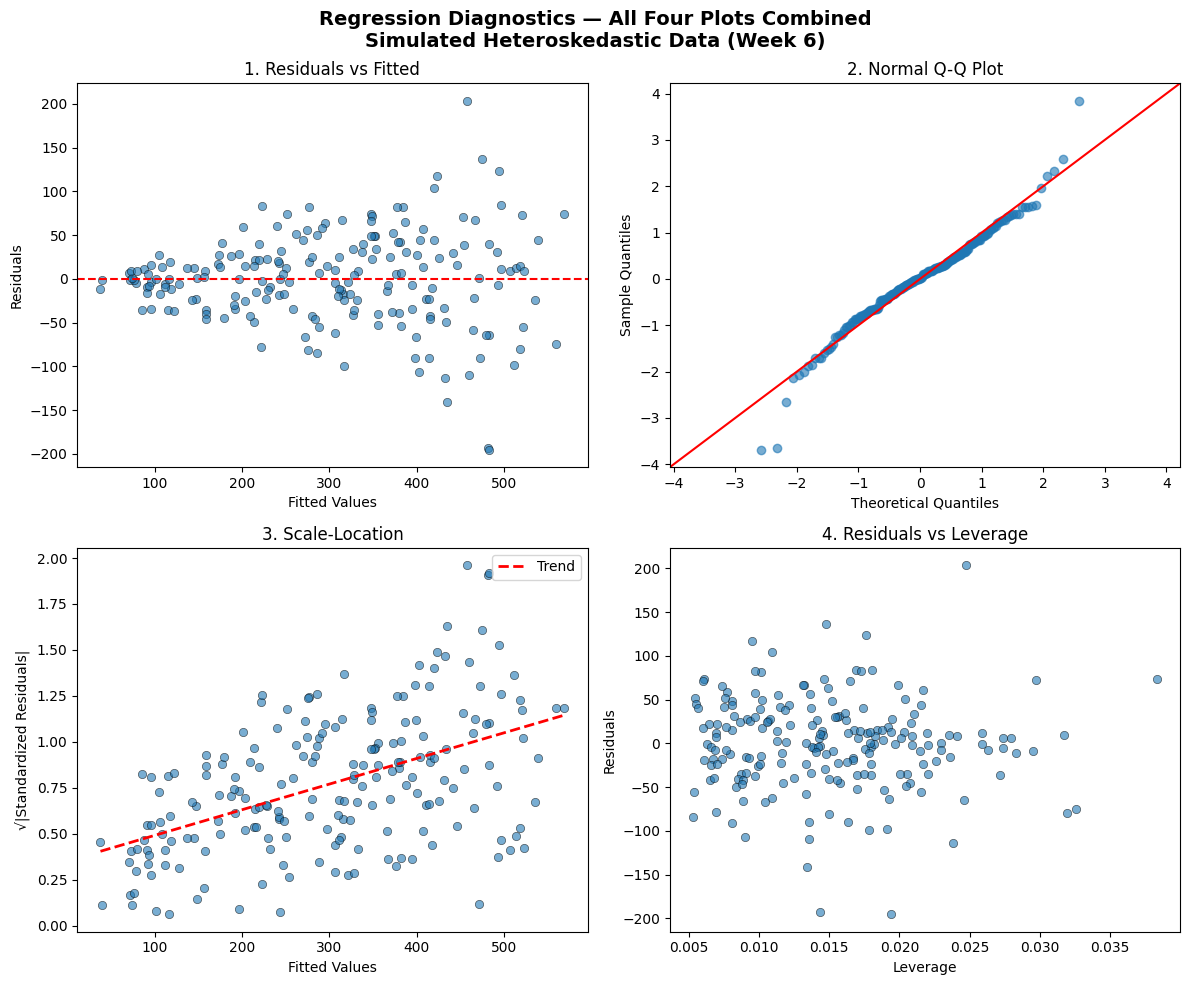

In [23]:
# Define all variables explicitly — easier for students to interpret
predicted_revenue = model.fittedvalues             # Predicted Revenue (ŷ)
residuals = model.resid                           # Residuals = actual Revenue − predicted Revenue
standardized_residuals = model.resid_pearson      # Standardized residuals (for Q-Q and scale-location)
leverage = model.get_influence().hat_matrix_diag   # Leverage: how far each observation's predictors are from the mean

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Regression Diagnostics — All Four Plots Combined\nSimulated Heteroskedastic Data (Week 6)', fontsize=14, fontweight='bold')

ax1 = axes[0, 0]
ax1.scatter(predicted_revenue, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('1. Residuals vs Fitted')

ax2 = axes[0, 1]
ProbPlot(standardized_residuals).qqplot(line='45', ax=ax2, alpha=0.6)
ax2.set_title('2. Normal Q-Q Plot')

ax3 = axes[1, 0]
ax3.scatter(predicted_revenue, np.sqrt(np.abs(standardized_residuals)), alpha=0.6, edgecolors='k', linewidth=0.5)
z = np.polyfit(predicted_revenue, np.sqrt(np.abs(standardized_residuals)), 1)
p = np.poly1d(z)
ax3.plot(sorted(predicted_revenue), p(sorted(predicted_revenue)), "r--", linewidth=2, label='Trend')
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('√|Standardized Residuals|')
ax3.set_title('3. Scale-Location')
ax3.legend()

ax4 = axes[1, 1]
ax4.scatter(leverage, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
ax4.set_xlabel('Leverage')
ax4.set_ylabel('Residuals')
ax4.set_title('4. Residuals vs Leverage')

plt.tight_layout()
out_path = OUTPUT_DIR / 'diagnostic_plots_simulated.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Define variables explicitly — easier for students to interpret
residuals = model.resid        # Residuals = actual Revenue − predicted Revenue
# X_design = design matrix (const + Firm_Size + Firm_Age) — already defined in Step 2

bp_test = het_breuschpagan(residuals, X_design)
bp_lm_stat = bp_test[0]
bp_lm_pval = bp_test[1]
use_robust = bp_lm_pval < 0.05

bp_results = pd.DataFrame({
    "Statistic": ["LM Statistic", "p-value", "Interpretation"],
    "Value": [
        f"{bp_lm_stat:.4f}",
        f"{bp_lm_pval:.6f}",
        "Reject H0 — heteroskedasticity detected (use robust SE)" if use_robust else "Fail to reject H0 — homoskedasticity OK"
    ]
})
display(bp_results.style.set_caption("Breusch-Pagan Test for Heteroskedasticity").set_properties(**{"text-align": "left"}))

,Statistic,Value
0,LM Statistic,27.9374
1,p-value,0.000001
2,Interpretation,Reject H0 — heteroskedasticity detected (use robust SE)


---

## Step 5: Robust Standard Errors (HC3)

We continue with our regression equation:

$$\text{Revenue} = \beta_0 + \beta_1 \cdot \text{Firm\_Size} + \beta_2 \cdot \text{Firm\_Age} + \varepsilon$$

Under heteroskedasticity, OLS standard errors are biased—they can be too small or too large, which makes confidence intervals and hypothesis tests unreliable. **HC3** (a type of heteroskedasticity-consistent standard error) corrects for this by allowing the variance of the errors to differ across observations. We compare OLS vs robust SE to see how much the standard errors change.

**Common practice in business and finance research:** Researchers almost always report robust standard errors (HC1, HC2, or HC3). Heteroskedasticity is the rule rather than the exception in cross-sectional and panel data, so using robust SE is standard practice—it does not change the coefficients, only the standard errors and thus the t-statistics and confidence intervals.

In [25]:
model_robust = model.get_robustcov_results(cov_type='HC3')

# Build comparison table — spell out each variable: intercept (const), Firm_Size, Firm_Age
variable_names = ['const', 'Firm_Size', 'Firm_Age']  # const = intercept, Firm_Size, Firm_Age
se_compare = pd.DataFrame({
    'Variable': variable_names,
    'OLS Coef': [model.params[v] for v in variable_names],
    'OLS SE': [model.bse[v] for v in variable_names],
    'Robust SE (HC3)': [model_robust.bse[i] for i in range(len(variable_names))],
})
se_compare['SE Change (%)'] = ((se_compare['Robust SE (HC3)'] - se_compare['OLS SE']) / se_compare['OLS SE'] * 100).round(1).astype(str) + '%'

display(se_compare.style.format({
    'OLS Coef': '{:.4f}',
    'OLS SE': '{:.4f}',
    'Robust SE (HC3)': '{:.4f}'
}).set_caption('OLS vs Robust (HC3) Standard Errors — Use robust SE when heteroskedasticity is detected.'))

,Variable,OLS Coef,OLS SE,Robust SE (HC3),SE Change (%)
0,const,20.4684,10.3866,8.5004,-18.2%
1,Firm_Size,0.5043,0.0142,0.0154,8.0%
2,Firm_Age,0.9383,0.2637,0.2673,1.4%


---

## Step 6: Variance Inflation Factor (VIF)

For our regression equation:

$$\text{Revenue} = \beta_0 + \beta_1 \cdot \text{Firm\_Size} + \beta_2 \cdot \text{Firm\_Age} + \varepsilon$$

**Multicollinearity** occurs when two or more predictors (here, Firm_Size and Firm_Age) are highly correlated, making it hard to isolate their individual effects and inflating standard errors. **VIF** (Variance Inflation Factor) measures how much the variance of a coefficient is inflated due to correlation with other predictors. Rule of thumb: VIF > 5 is concerning, VIF > 10 indicates serious multicollinearity. Low VIF (near 1) means predictors are largely independent.

In [26]:
# Predictors in our regression: Firm_Size and Firm_Age (no constant — VIF is for predictors only)
X_predictors_Firm_Size_Firm_Age = df[['Firm_Size', 'Firm_Age']]
vif_data = pd.DataFrame({
    "Variable": X_predictors_Firm_Size_Firm_Age.columns,
    "VIF": [variance_inflation_factor(X_predictors_Firm_Size_Firm_Age.values, i) for i in range(X_predictors_Firm_Size_Firm_Age.shape[1])]
})
display(vif_data.style.format({"VIF": "{:.2f}"}).set_caption("Variance Inflation Factor (VIF) — Rule of thumb: VIF > 5 concerning, VIF > 10 serious"))

,Variable,VIF
0,Firm_Size,2.43
1,Firm_Age,2.43


---

## Key Takeaways

1. **Regression equation**: Revenue = β₀ + β₁(Firm_Size) + β₂(Firm_Age) + ε — the estimated coefficients appear in the OLS table above.
2. **This data shows clear heteroskedasticity** — funnel pattern in Residuals vs Fitted
3. **Breusch-Pagan test detects it** — p < 0.05, so we reject homoskedasticity
4. **Robust SE differ from OLS SE** — always use robust SE when heteroskedasticity is present
5. **VIF shows no multicollinearity** — Firm_Size and Firm_Age are independent (good!)

This is a complete teaching example for Week 6 regression diagnostics.